# Statistical Arbitrage - Results and Analysis

This notebook visualizes the full pipeline:
**pair selection → Kalman Filter estimation → signal generation → backtest performance**.

All heavy computation runs in `main.py` and the results are loaded from `.parquet` files.
This notebook is purely for exploration and presentation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import statsmodels.api as sm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from main import BacktestOrchestrator
from src.plotting import Plotter
from src.half_life import StationarityAnalyzer
from src.kalman_filter import KalmanFilterPairs
from src.strategy import StatArbStrategy
from src.storage import DataStorage

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Configuration

These parameters must match the ones used in `main.py` exactly.
Changing them here re-runs only the visualisation steps (KF + signals), not the full scan.

In [2]:
import json, os

DATA_DIR       = '../data'
TICKER_GROUP   = 'new_sample'
TRAIN_START    = '2011-01-01'
TRAIN_END      = '2016-12-31'
TEST_START     = '2017-01-01'
TEST_END       = '2018-12-31'

ENTRY_Z        = 2.0
EXIT_Z         = 0.0
INIT_CAP       = 100_000
USE_LOG_PRICES = True

storage = DataStorage(data_dir=DATA_DIR)

# Load saved pair metadata generated by main.py (run main.py first).
_metadata_path = os.path.join(DATA_DIR, 'top_pairs_metadata.json')
if os.path.exists(_metadata_path):
    with open(_metadata_path) as f:
        _raw = json.load(f)
    TOP_PAIRS = [{**p, "pair": tuple(p["pair"])} for p in _raw]
    print(f"Loaded {len(TOP_PAIRS)} pairs from top_pairs_metadata.json")
else:
    print("top_pairs_metadata.json not found — re-running pair selection (run main.py to cache results).")
    app = BacktestOrchestrator(
        data_dir=DATA_DIR,
        tickers_file='../data/Tickers.json',
        ticker_group=TICKER_GROUP,
        train_start=TRAIN_START, train_end=TRAIN_END,
        test_start=TEST_START, test_end=TEST_END,
        top_n_pairs=5, entry_z=ENTRY_Z, exit_z=EXIT_Z,
        initial_capital=INIT_CAP,
        use_log_prices=USE_LOG_PRICES,
    )
    app.load_tickers()
    TOP_PAIRS = app.select_top_pairs()
    print(f"Config loaded. {len(TOP_PAIRS)} pairs selected.")

print("Pairs:", [f"{p['pair'][0]}/{p['pair'][1]}" for p in TOP_PAIRS])

Loaded 5 pairs from top_pairs_metadata.json
Pairs: ['AAPL/GOOGL', 'COP/SLB', 'SHEL/XOM', 'AMD/NVDA', 'PEP/PG']


---
## Section 1 — Pair Selection and Cointegration

The Engle-Granger two-step procedure identifies pairs whose price spread is stationary:
1. Regress Y on X via OLS to extract the residual spread.
2. Apply the ADF test on the residuals: a low p-value means the spread is mean-reverting.

We further filter by **half-life** (5–30 days) to ensure the mean reversion is fast enough
to be exploitable at daily frequency without excessive transaction cost drag.

In [3]:
# Load training prices from new_sample group
import json, os
with open(os.path.join(DATA_DIR, 'Tickers.json')) as f:
    tickers_cfg = json.load(f)

tickers = tickers_cfg.get(TICKER_GROUP, tickers_cfg.get('tickers'))

print('Fetching training data...')
raw = yf.download(tickers, start=TRAIN_START, end=TRAIN_END, progress=False)
train_prices = raw['Close'].ffill().dropna(how='all')
available = train_prices.columns[train_prices.notna().sum() > 200].tolist()
print(f'{len(available)} tickers with sufficient data from {TICKER_GROUP}.')

Fetching training data...


$MRO: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found

2 Failed downloads:
['MRO', 'JNPR']: possibly delisted; no timezone found


27 tickers with sufficient data from new_sample.


In [4]:
# Build p-value matrix for heatmap (subset for readability — first 20 tickers)
HEATMAP_TICKERS = available[:20]
n = len(HEATMAP_TICKERS)
pval_matrix = np.ones((n, n))

for i, j in itertools.combinations(range(n), 2):
    pair_data = train_prices[[HEATMAP_TICKERS[i], HEATMAP_TICKERS[j]]].dropna()
    if len(pair_data) < 200:
        continue
    try:
        res = sm.OLS(pair_data.iloc[:, 0], sm.add_constant(pair_data.iloc[:, 1])).fit()
        _, pval = StationarityAnalyzer.check_stationarity(res.resid)
        pval_matrix[i, j] = pval_matrix[j, i] = pval
    except Exception:
        pass

print('P-value matrix computed.')

P-value matrix computed.


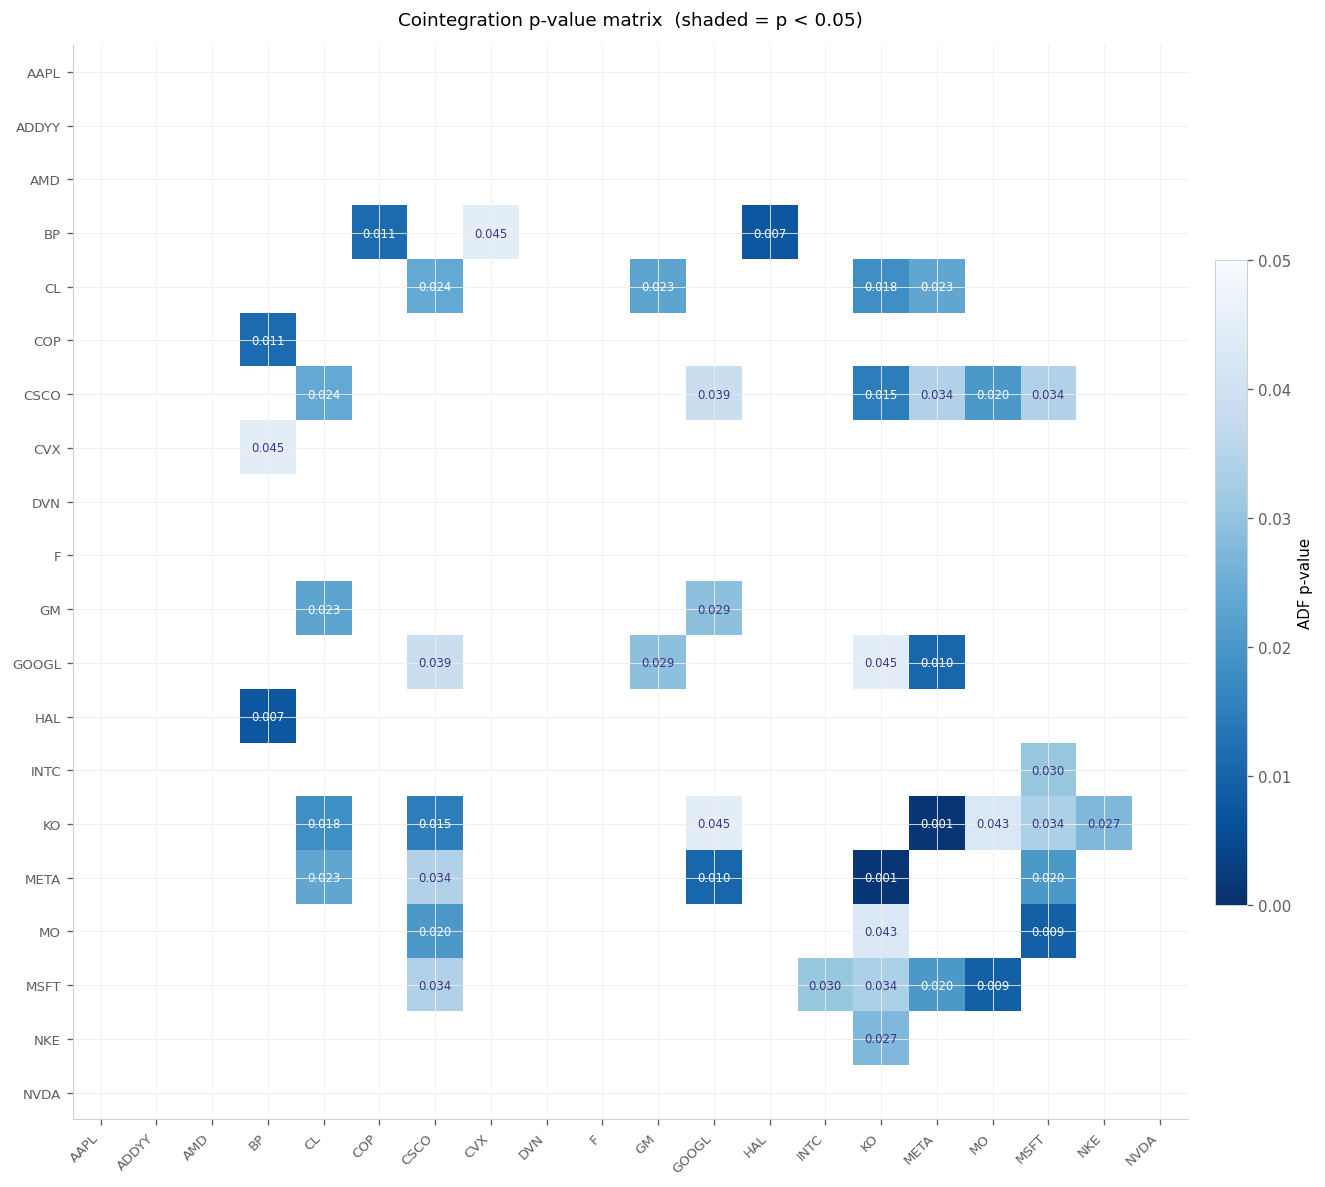

In [5]:
fig = Plotter.cointegration_heatmap(pval_matrix, HEATMAP_TICKERS)
plt.show()

Only shaded cells pass the 5% significance threshold.
Darker blue = stronger evidence of cointegration (lower p-value).
Grey cells represent pairs that failed the ADF test.

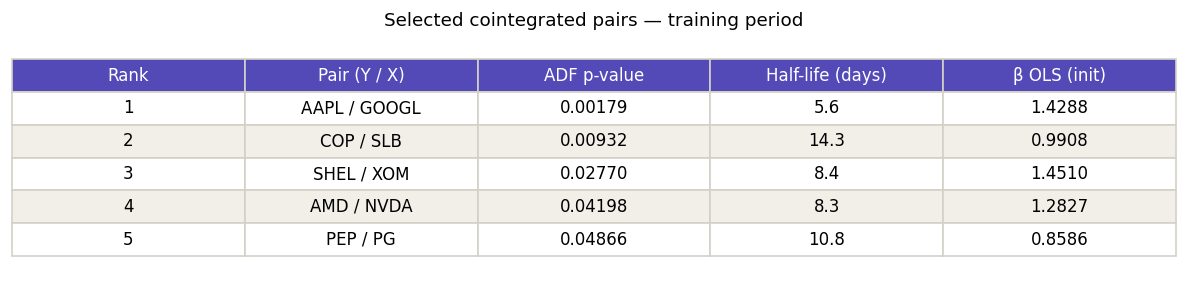

In [6]:
# Selected pairs summary table
if TOP_PAIRS:
    fig = Plotter.pairs_summary_table(TOP_PAIRS)
    plt.show()
else:
    print('Fill in TOP_PAIRS in the Configuration cell, then re-run.')

This table summarizes the final candidates that passed statistical filters and ranking logic.
Key diagnostics (such as p-values, half-life, and initialization parameters) explain why each pair was retained.
These pairs define the strategy universe for Kalman filtering, signal generation, and backtesting.

---
## Section 2 — Kalman Filter and Spread

For each selected pair, the **Kalman Filter** estimates a time-varying hedge ratio β_t.
This is more realistic than a static OLS beta because the true relationship between two stocks
drifts over time as business conditions change.

The spread signal is the Kalman innovation **before** the update step, `e_t`. It is standardized as filter Z-score:

`z_t = e_t / sqrt(S_t)`

where `S_t` is the innovation variance produced by the filter at time `t`. No rolling-window normalization is used.

In [7]:
if not TOP_PAIRS:
    print('Fill in TOP_PAIRS first.')
else:
    # Fetch test prices for all selected tickers
    test_tickers = list({t for p in TOP_PAIRS for t in p['pair']})
    raw_test = yf.download(test_tickers, start=TEST_START, end=TEST_END, progress=False)
    test_prices = raw_test['Close'].ffill().dropna(how='all')
    print(f'Test data loaded: {len(test_prices)} trading days.')

Test data loaded: 501 trading days.


The reported trading-day count is the effective horizon on which strategy behavior is evaluated.
If this count is unexpectedly short, performance metrics may be noisy and less reliable.

In [8]:
# Compute KF states, innovations and Z-scores for each pair — stored for later plots
pair_data_cache = {}  # key = (Y, X)

for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    df_pair = test_prices[[Y, X]].dropna()
    y_arr, x_arr, dates = df_pair[Y].values, df_pair[X].values, df_pair.index

    # Match main.py: low-noise params for log-prices, warm-start from OLS beta + alpha
    kf = KalmanFilterPairs(
        observation_variance=1e-4,
        delta_beta=1e-6,
        delta_alpha=1e-6,
    )
    states, innovations, innovation_vars = kf.filter(
        y_arr, x_arr,
        beta_init=pair_info['beta_init'],
        alpha_init=pair_info.get('alpha_init'),
        use_log_prices=USE_LOG_PRICES,
    )
    betas = states[:, 0]

    strategy = StatArbStrategy(entry_z=ENTRY_Z, exit_z=EXIT_Z)
    signals_df = strategy.generate_signals(innovations, innovation_vars)
    signals_df.index = dates

    pair_data_cache[(Y, X)] = dict(
        y_arr=y_arr, x_arr=x_arr, dates=dates,
        betas=betas,
        innovations=innovations,
        innovation_vars=innovation_vars,
        zscore=signals_df['Z_Score'].values,
        signals_df=signals_df,
    )

print('KF and signals computed for all pairs.')

KF and signals computed for all pairs.


The cache now contains all intermediate objects needed for diagnostic plots and trading analysis.
At this stage, the model has transformed raw prices into tradable mean-reversion signals.



── AAPL vs GOOGL ──


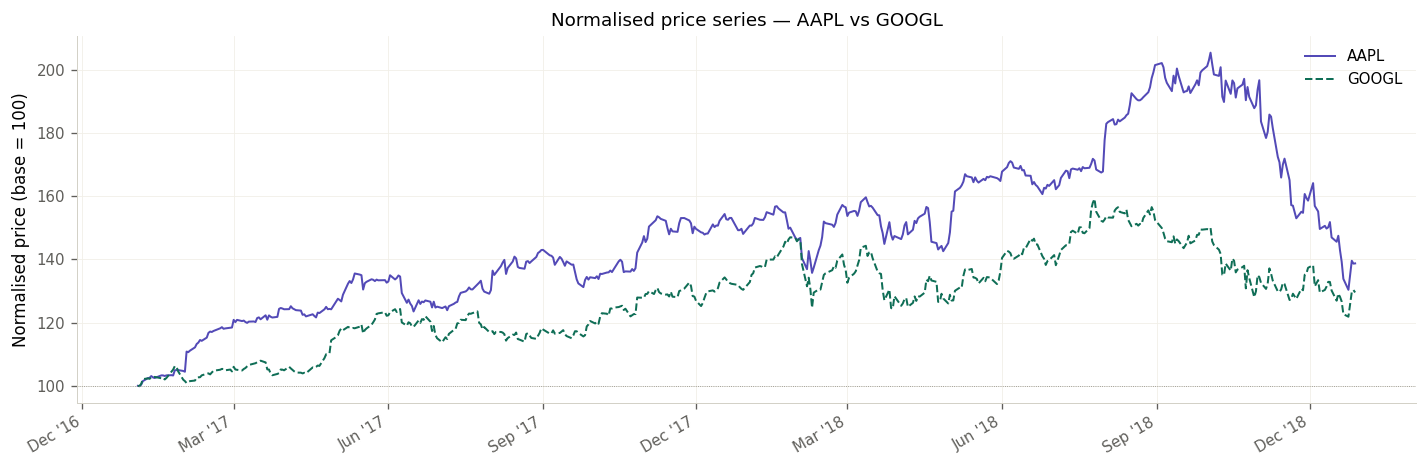

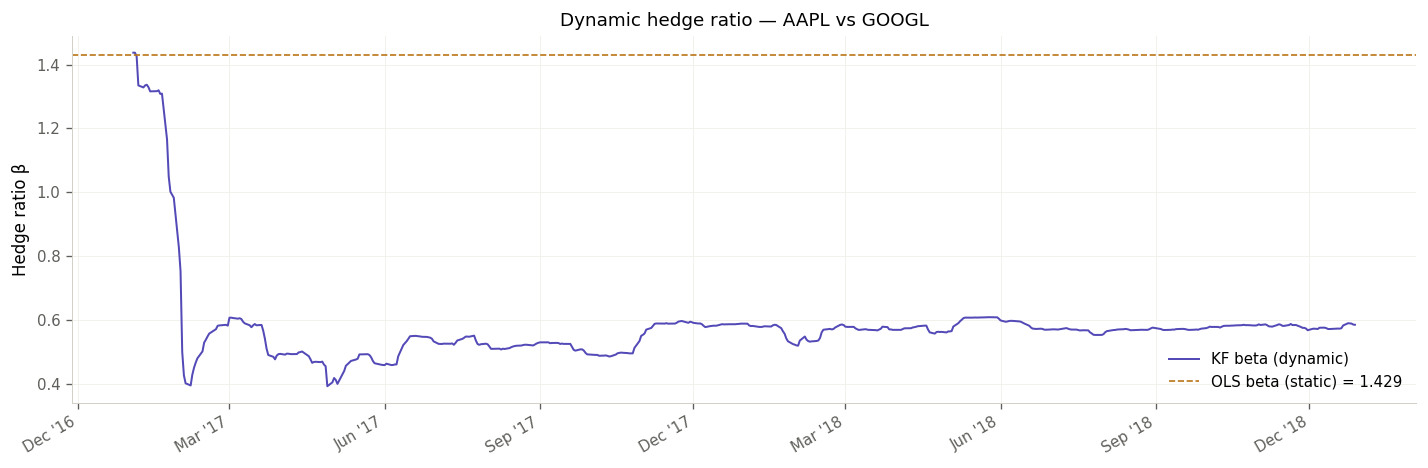

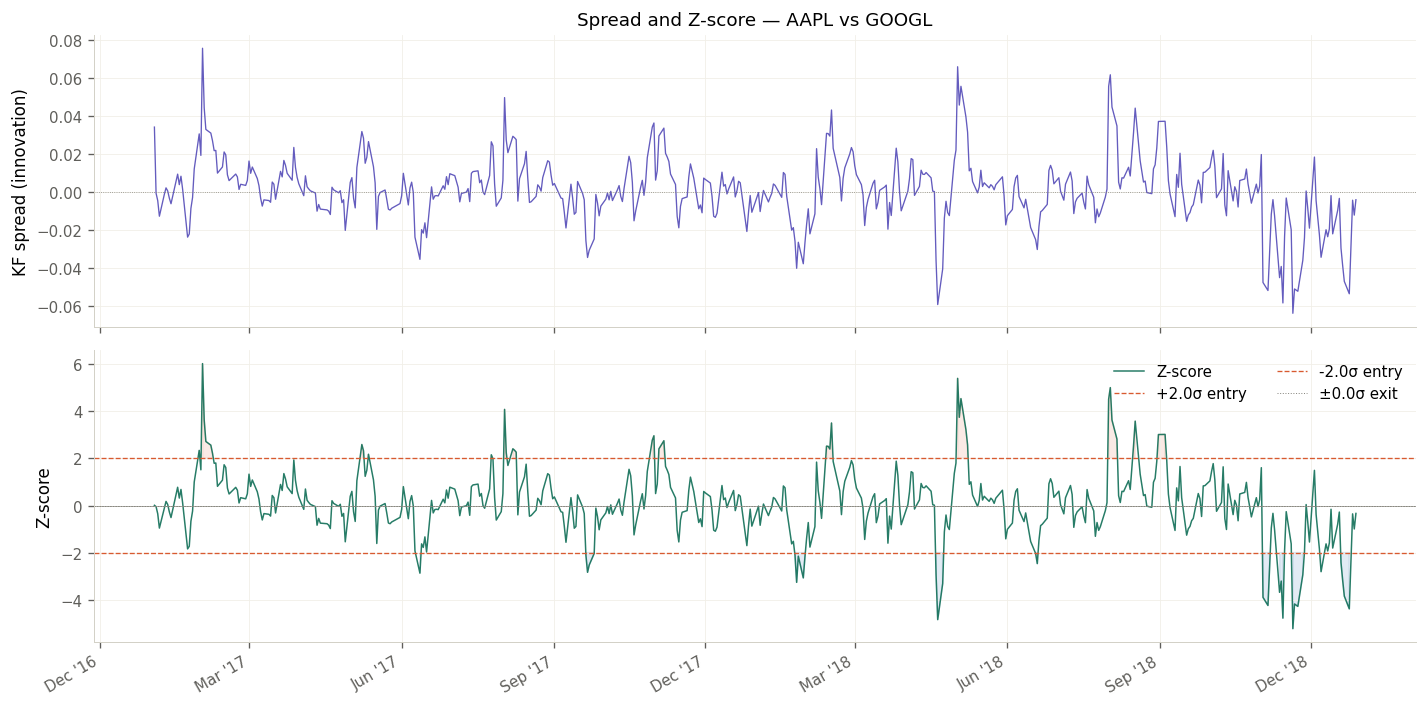


── COP vs SLB ──


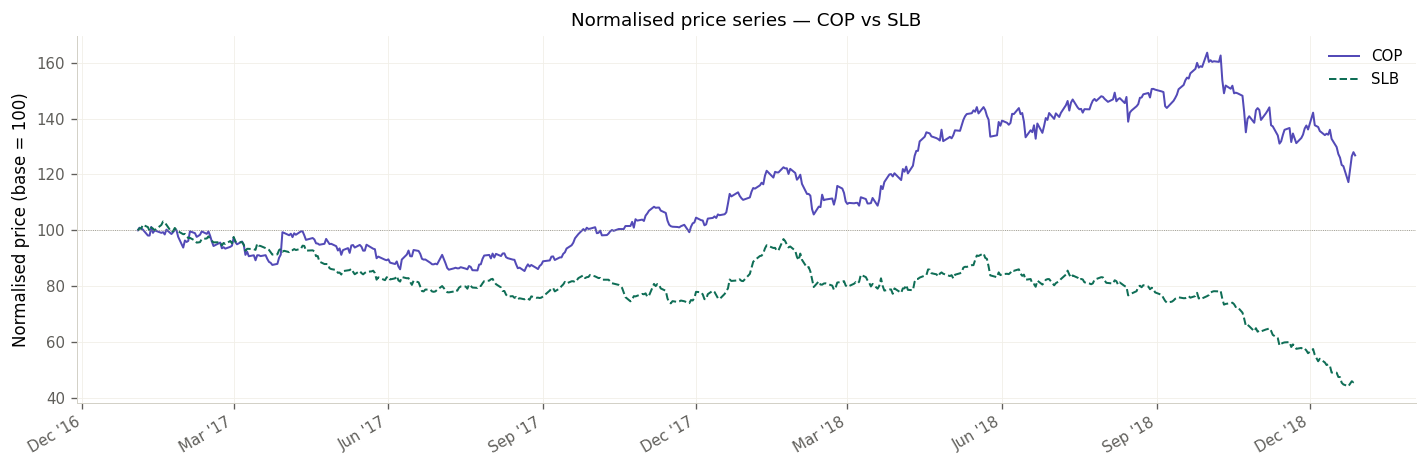

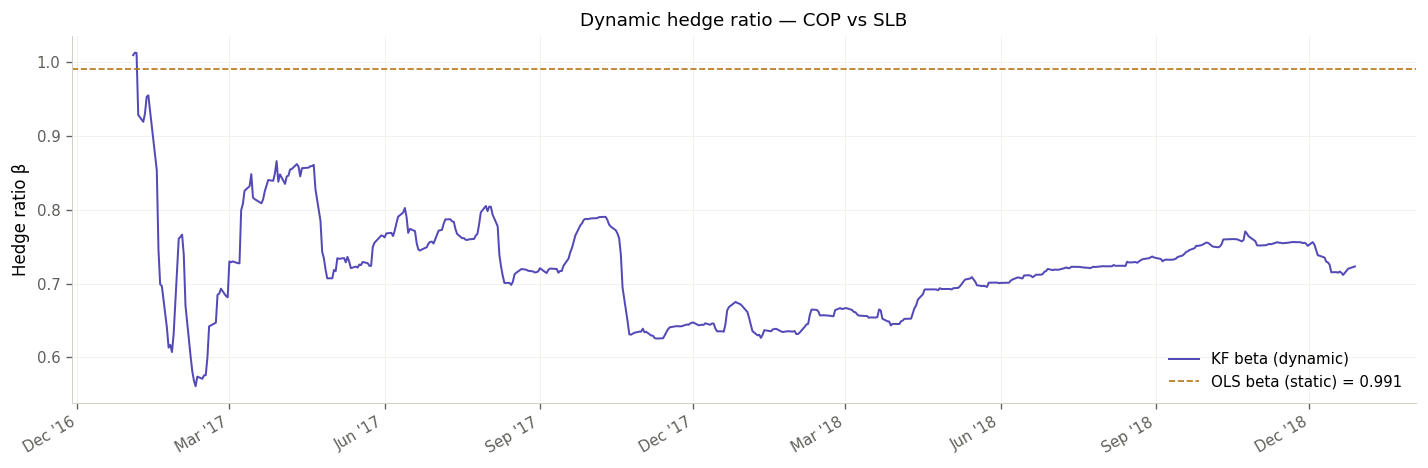

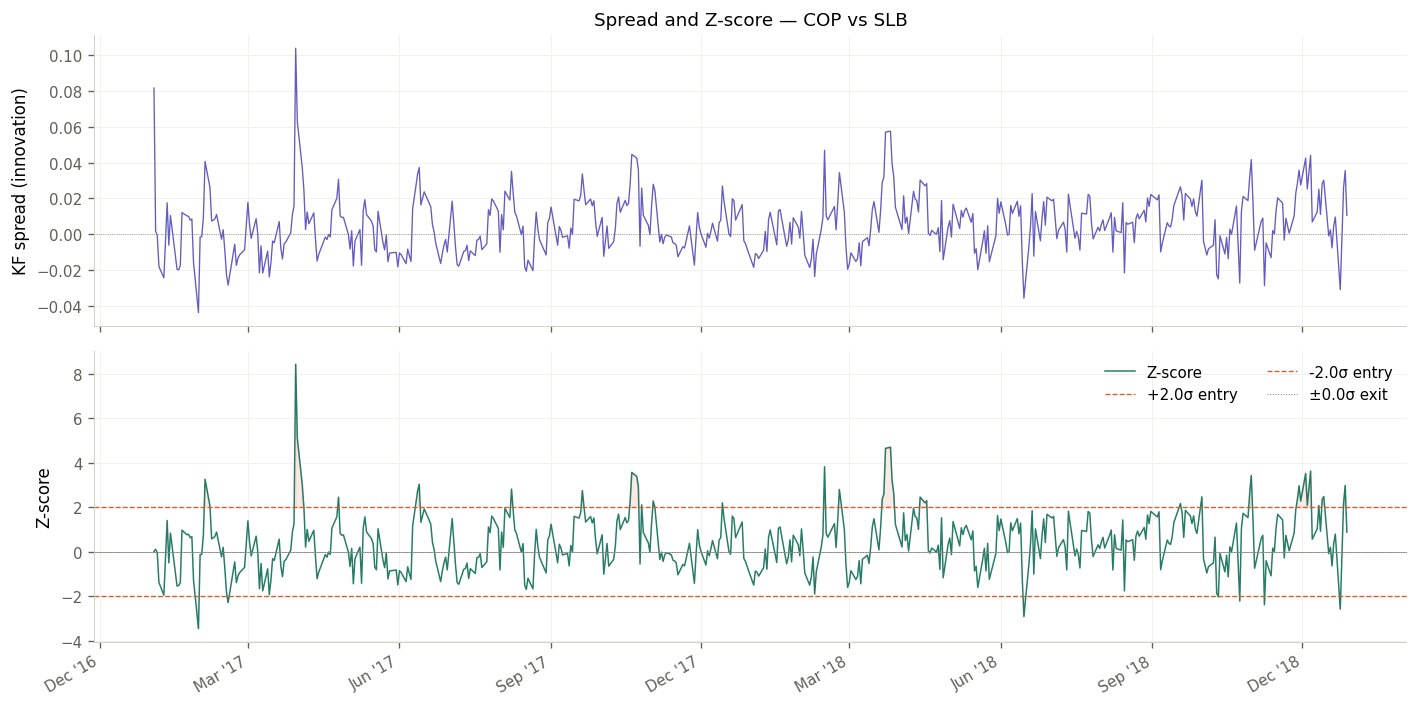


── SHEL vs XOM ──


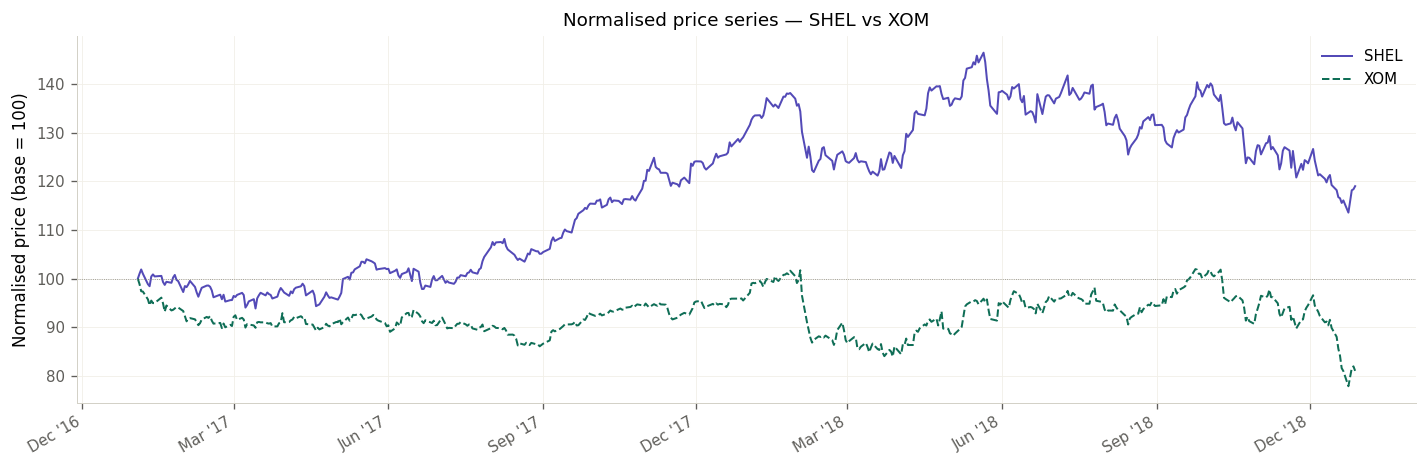

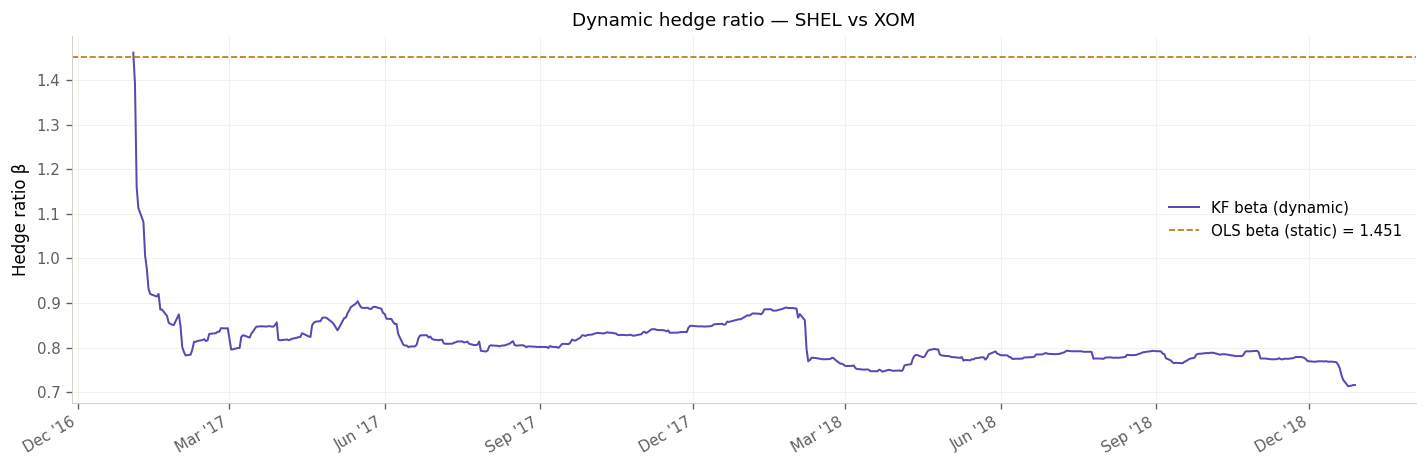

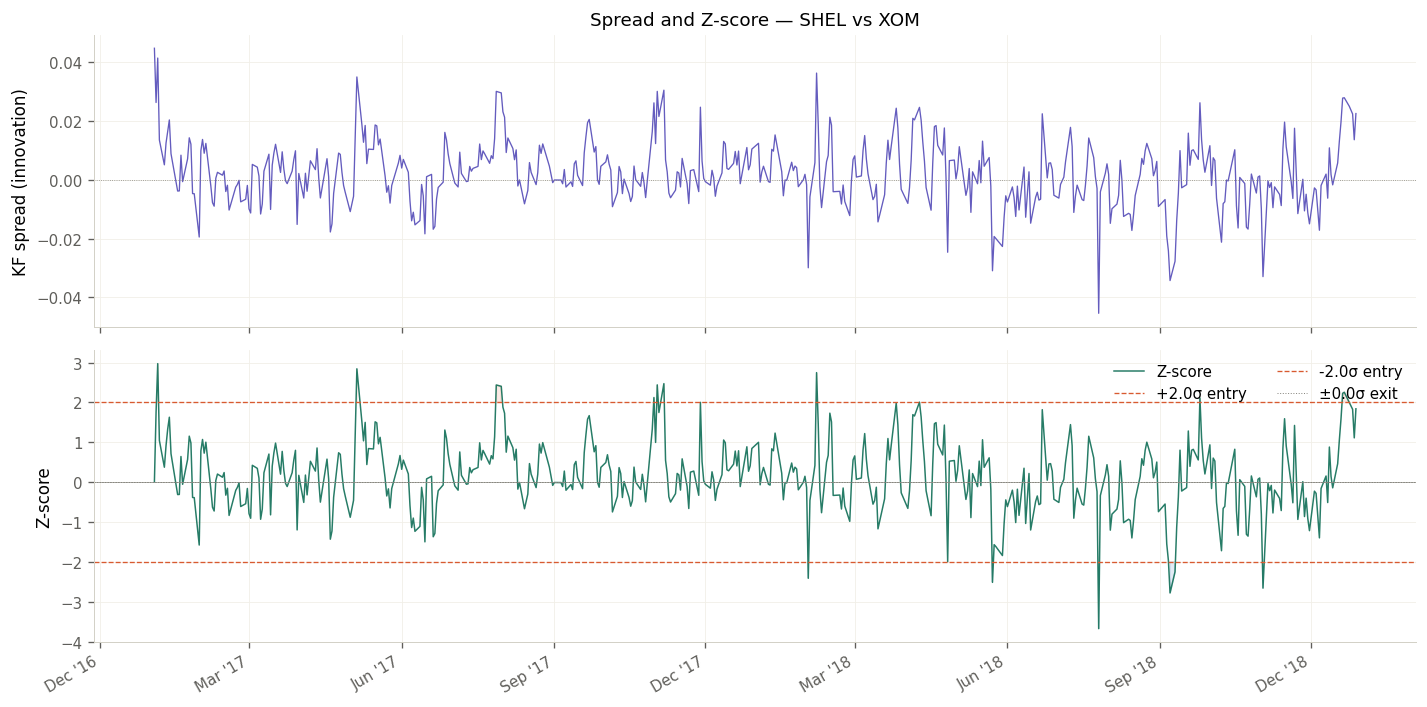


── AMD vs NVDA ──


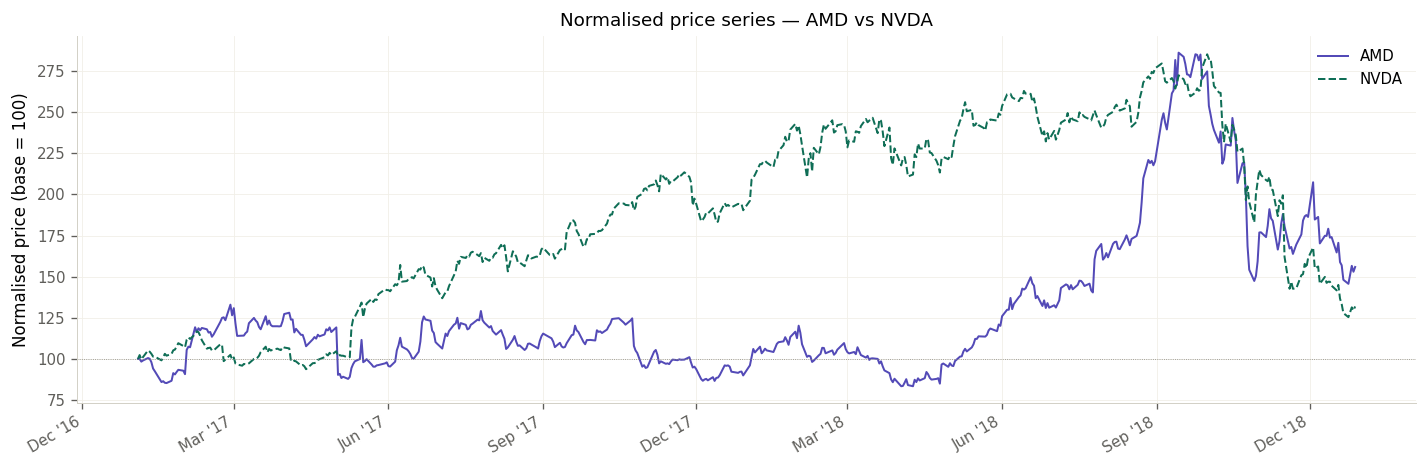

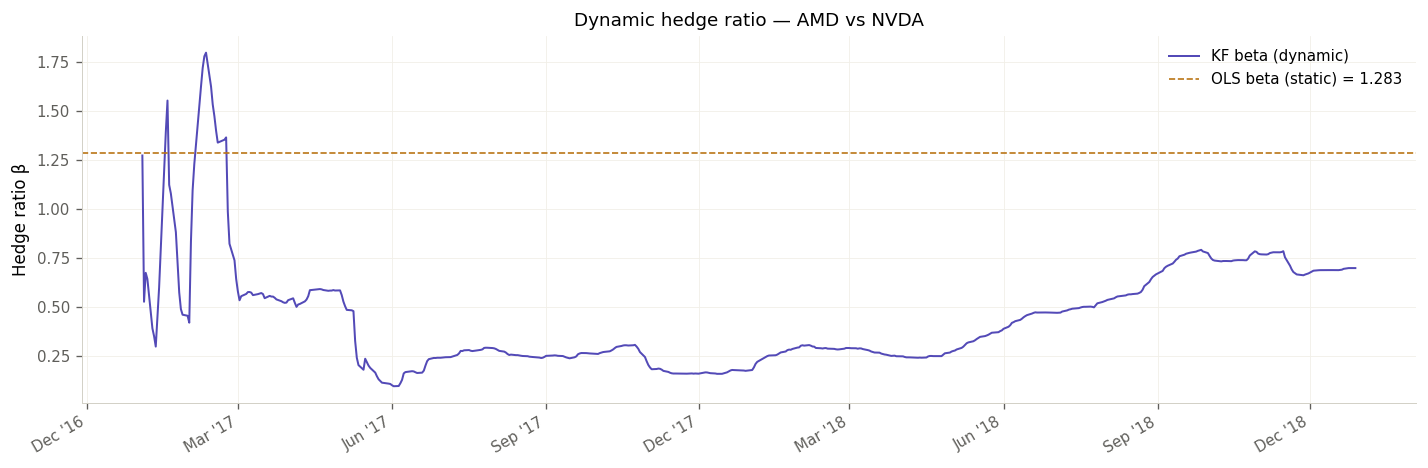

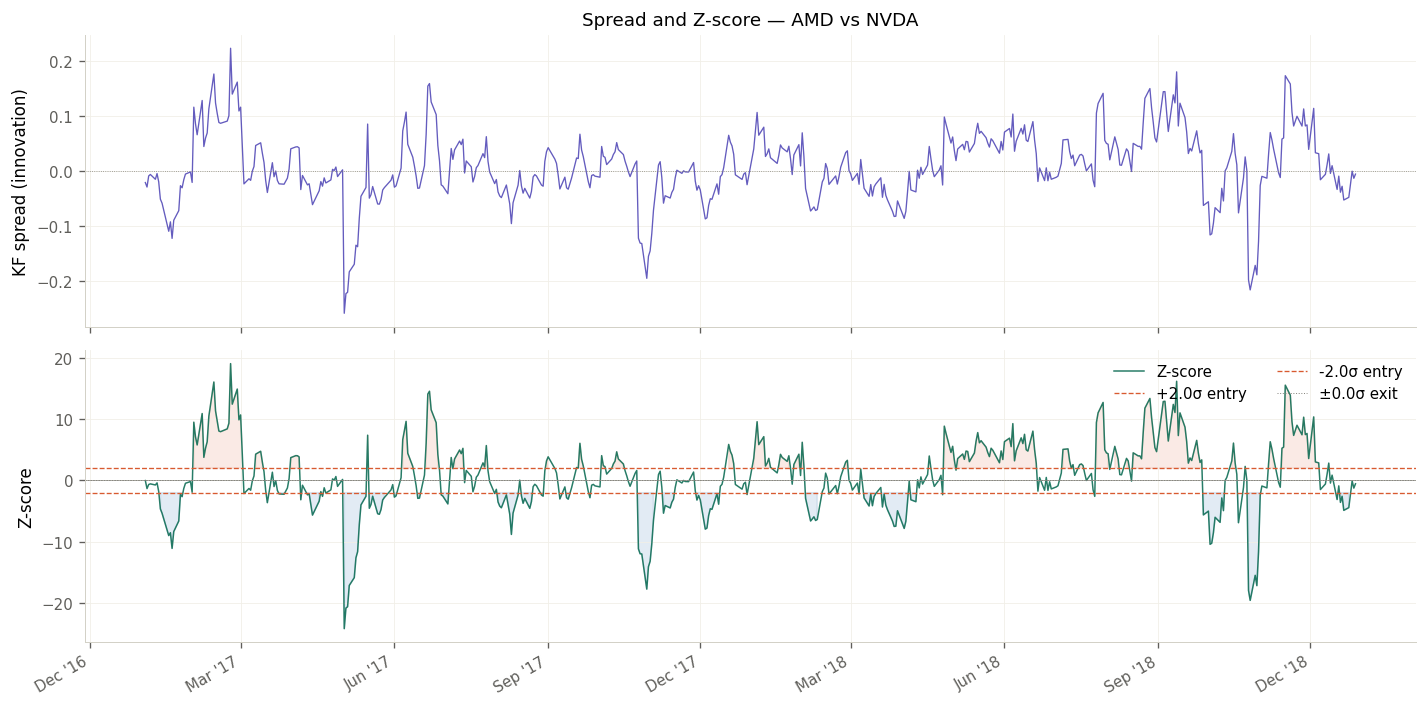


── PEP vs PG ──


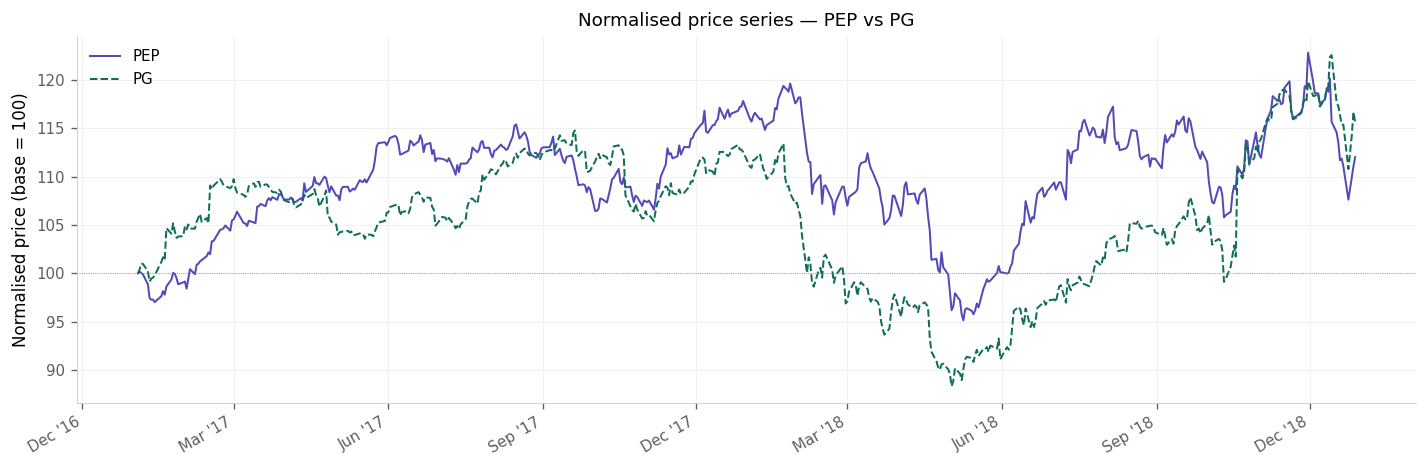

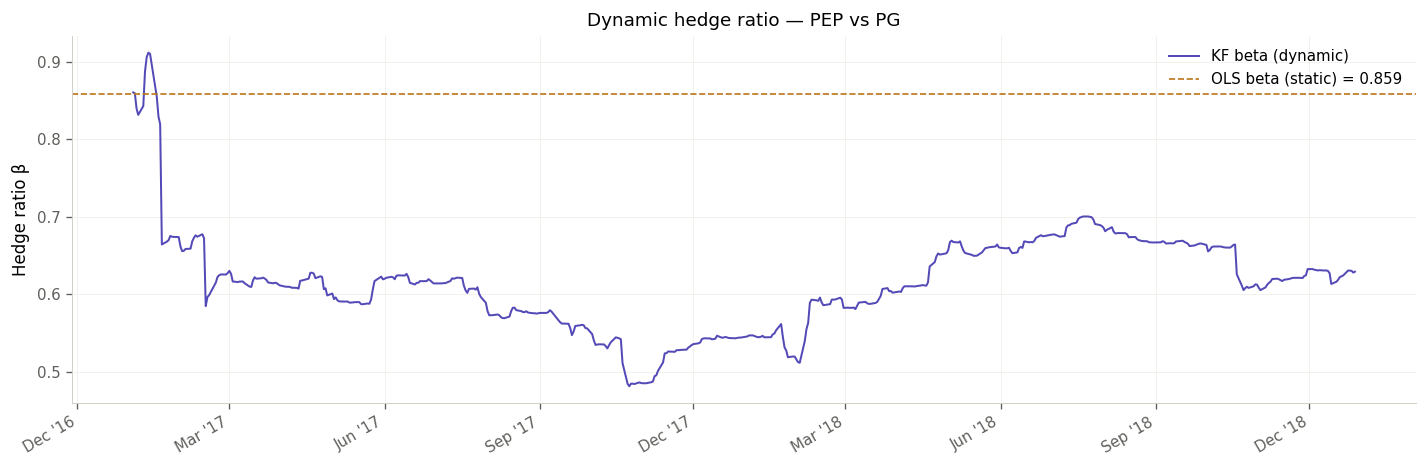

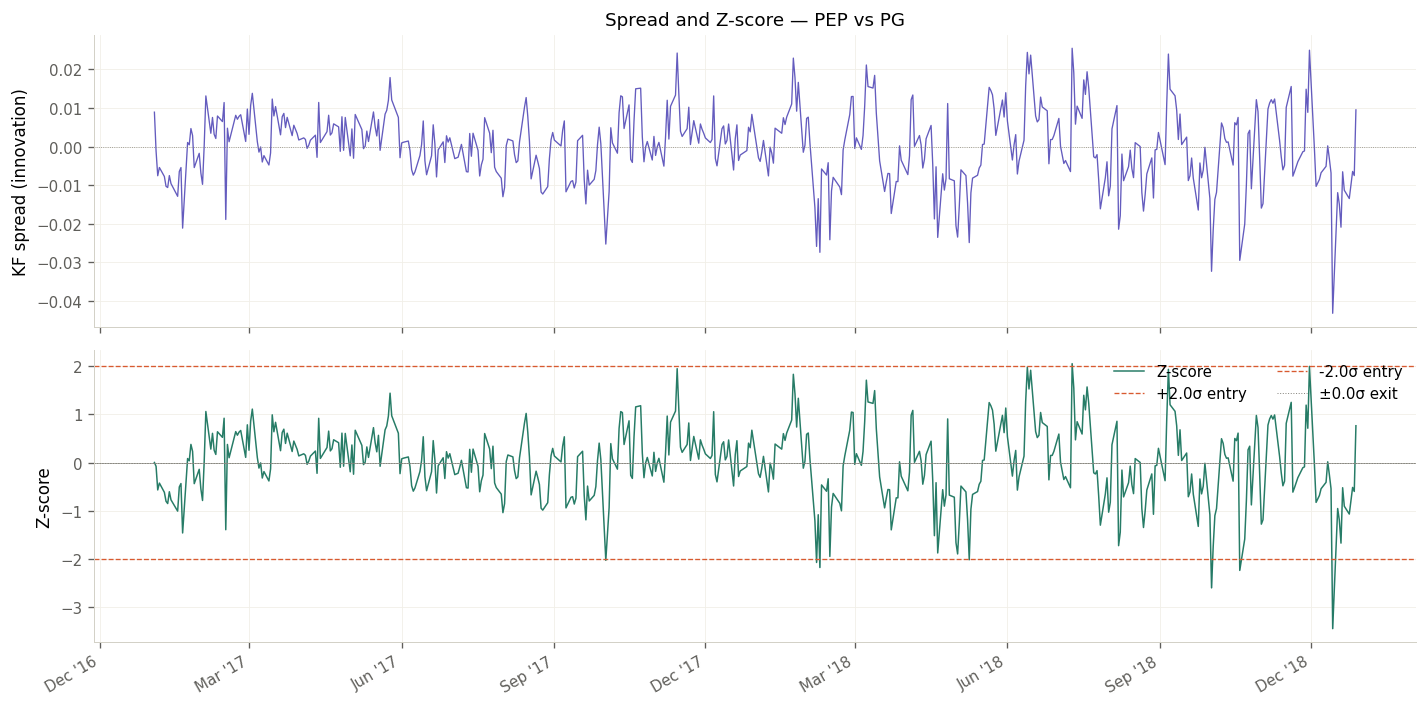

In [9]:
# Plot for each pair
for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    d = pair_data_cache[(Y, X)]

    print(f'\n── {Y} vs {X} ──')

    fig = Plotter.normalized_prices(d['y_arr'], d['x_arr'], d['dates'], Y, X)
    plt.show()

    fig = Plotter.dynamic_beta(d['betas'], pair_info['beta_init'], d['dates'], Y, X)
    plt.show()

    fig = Plotter.spread_and_zscore(
        d['innovations'], d['zscore'], d['dates'], Y, X,
        entry_z=ENTRY_Z, exit_z=EXIT_Z
    )
    plt.show()

For each pair, the three charts should be read together: relative price co-movement, time-varying hedge ratio, and spread Z-score dynamics.
A stable beta with repeated Z-score mean reversion supports the statistical arbitrage premise.
Large regime shifts or persistent Z-score drift may indicate weakening cointegration and elevated model risk.


### Example pair: AAPL/GOOGL
In the **normalized price** plot, this pair often shows periods of divergence followed by re-alignment, which is the visual signature we want before mean reversion trades.
In the **dynamic beta** plot, the hedge ratio adjusts smoothly over time rather than remaining fixed, indicating that the filter is adapting to changing relative sensitivity between the two assets.
In the **spread and Z-score** plot, large absolute Z-score moves tend to appear when normalized prices temporarily decouple; as prices converge again, the Z-score returns toward zero and confirms the reversion cycle.

Taken together, the three plots describe one coherent mechanism: temporary relative mispricing (plot 1), adaptive hedging response (plot 2), and statistically normalized entry/exit pressure (plot 3).

---
## Section 3 — Strategy and Signal Analysis

Entry and exit rules are based on the Z-score:
- **Long spread** (long Y, short X): when Z-score ≤ −`entry_z`  
- **Short spread** (short Y, long X): when Z-score ≥ +`entry_z`  
- **Exit**: when |Z-score| reverts to ≤ `exit_z`

Position sizing is adaptive: the allocation scales with Z-score magnitude
(0.5× at |z| ∈ (1, 1.5), 0.75× at (1.5, 2), 0.9× at (2, 2.5), 1× at ≥ 2.5).

To prevent look-ahead bias, all signals are shifted by one day before execution:
the signal generated on day t is executed at the open of day t+1.


── AAPL vs GOOGL ──


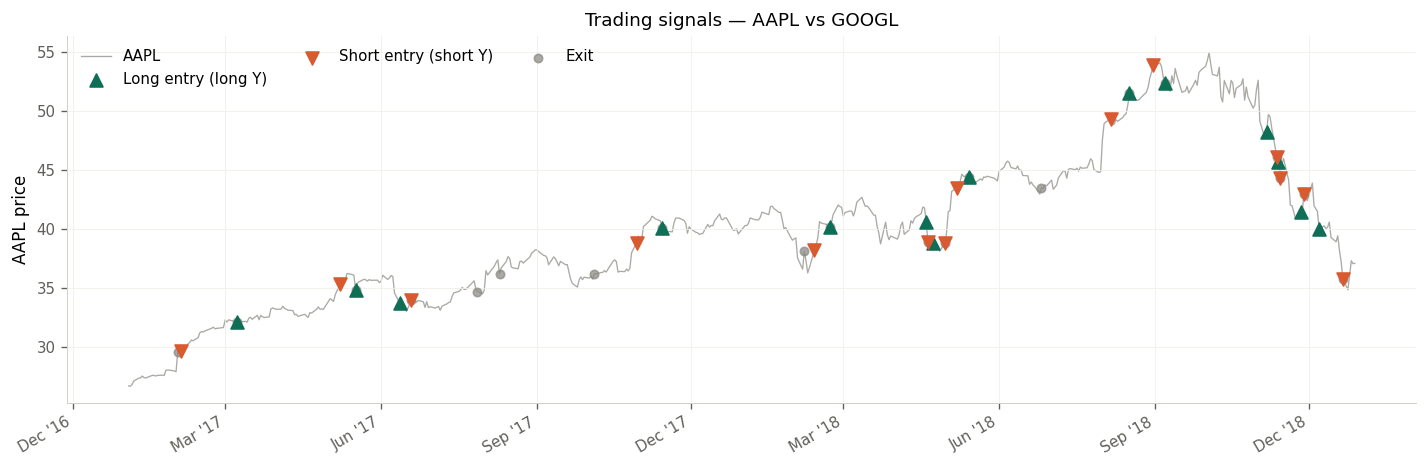

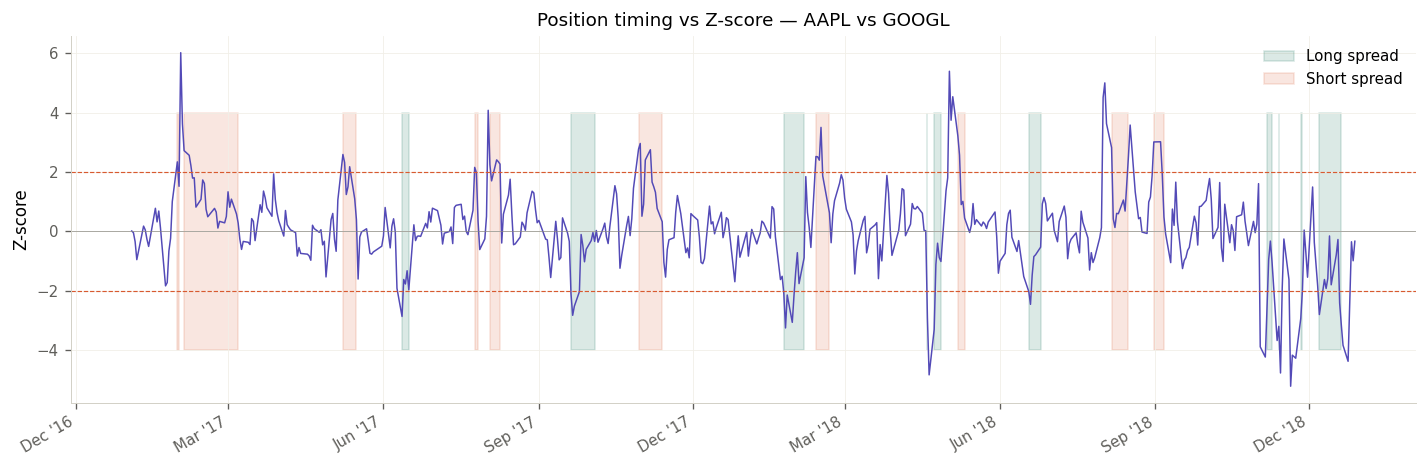


── COP vs SLB ──


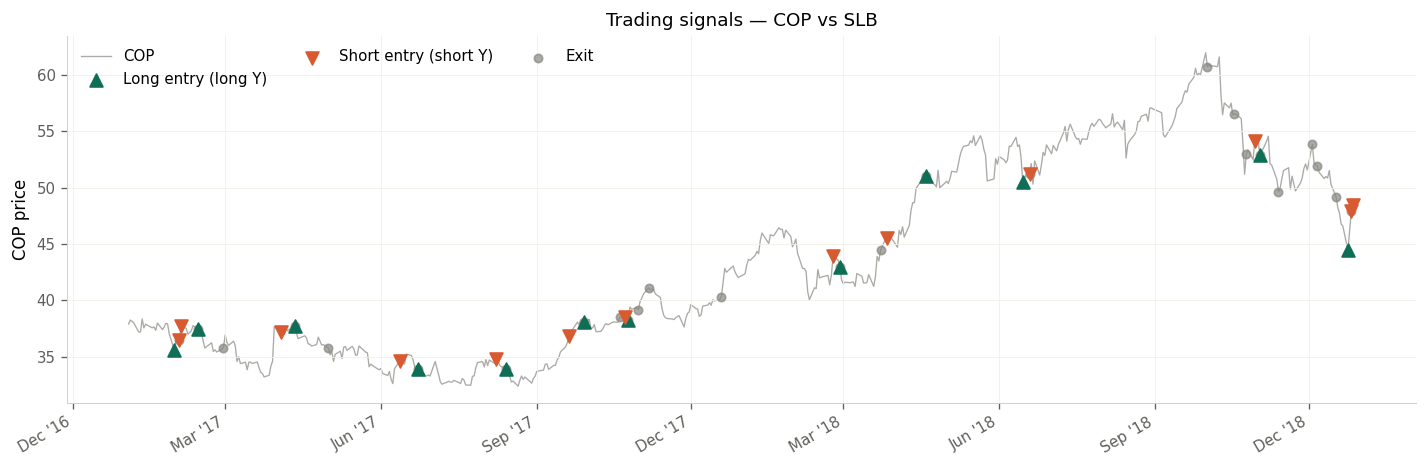

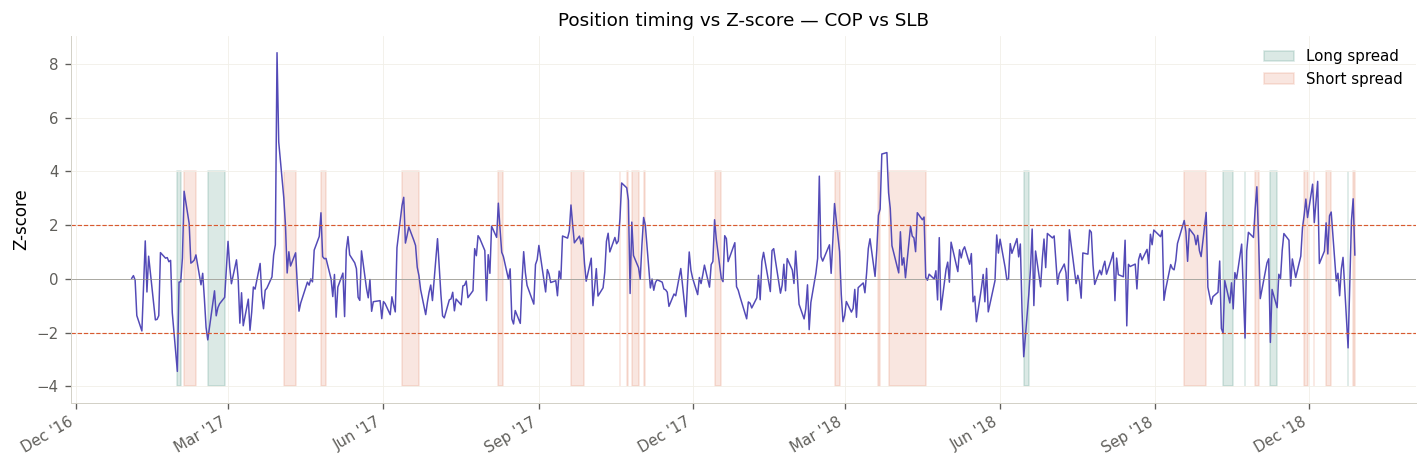


── SHEL vs XOM ──


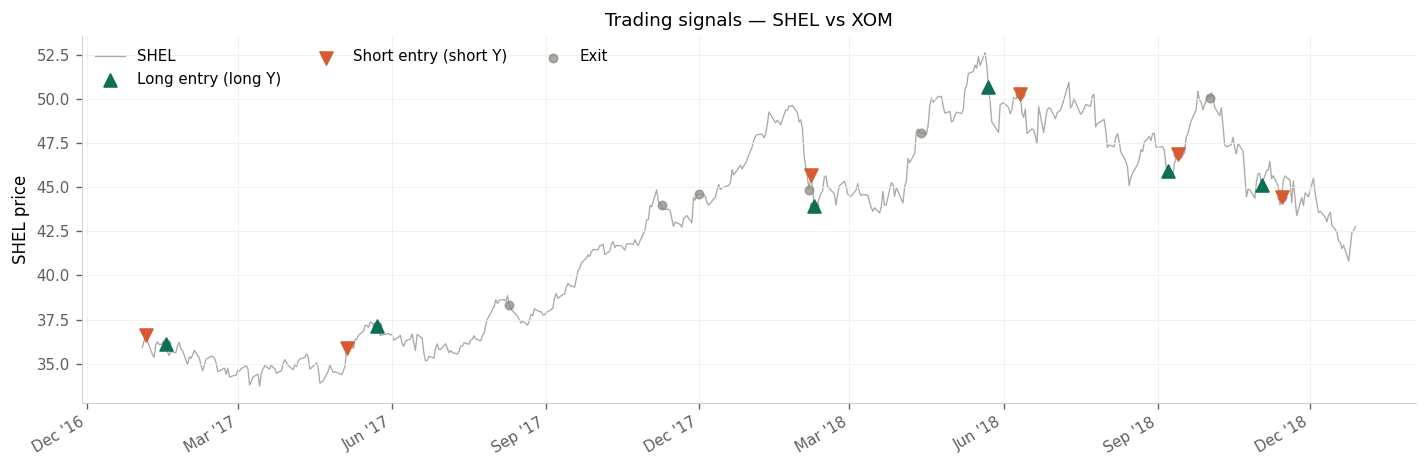

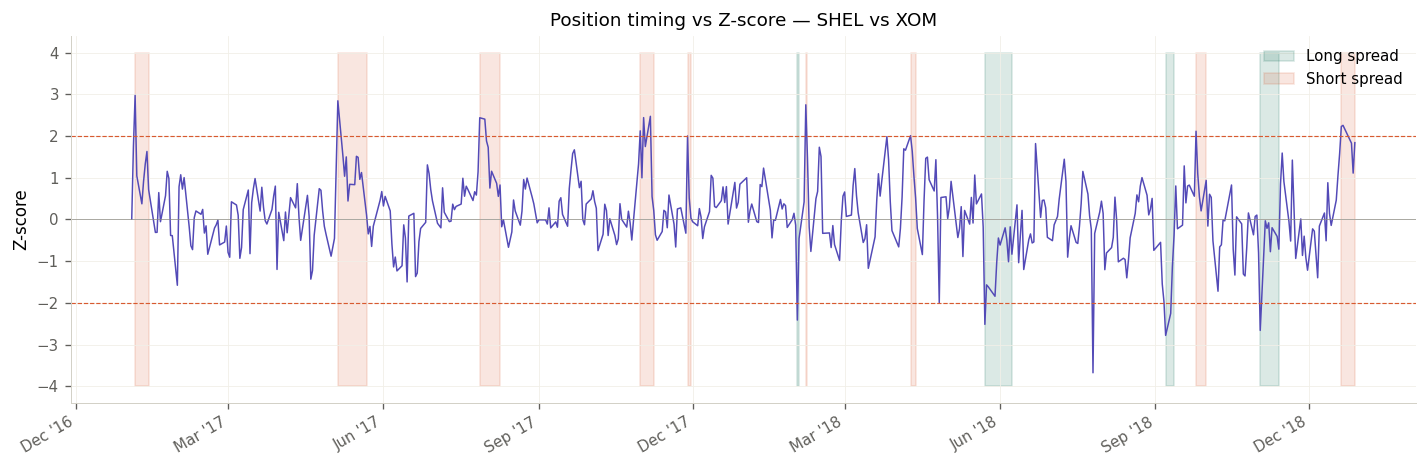


── AMD vs NVDA ──


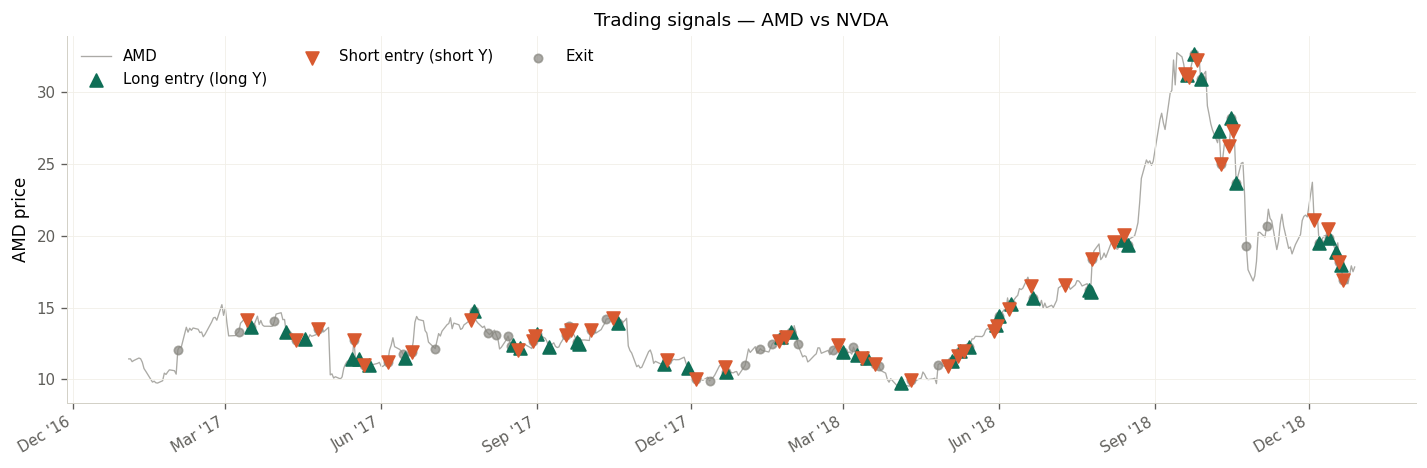

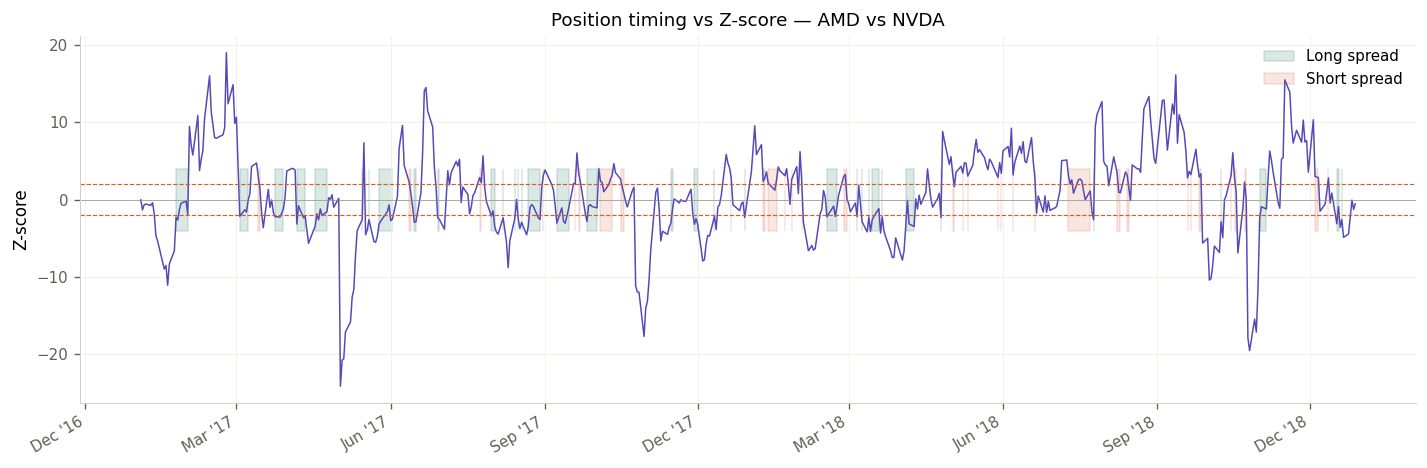


── PEP vs PG ──


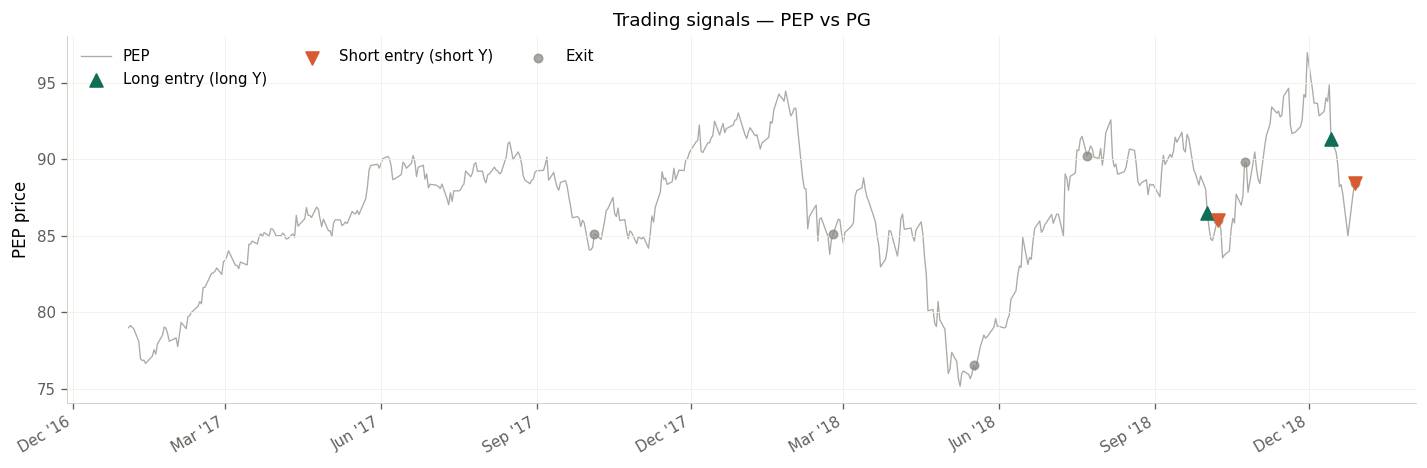

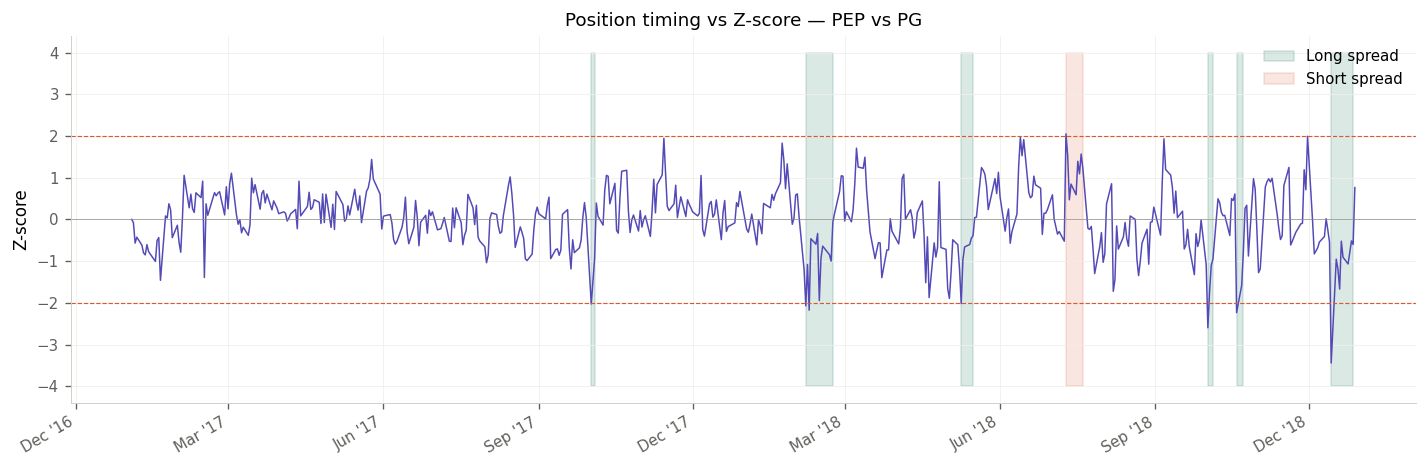

In [10]:
for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    d = pair_data_cache[(Y, X)]
    print(f'\n── {Y} vs {X} ──')

    fig = Plotter.trading_signals(d['y_arr'], d['signals_df'], d['dates'], Y, X)
    plt.show()

    fig = Plotter.position_and_zscore(
        d['zscore'], d['signals_df'], d['dates'], Y, X, entry_z=ENTRY_Z
    )
    plt.show()

These charts show where entry/exit events occurred and how exposure evolved with signal strength.
Healthy behavior typically shows positions building at extremes and flattening near mean reversion.
Frequent whipsaws around the threshold suggest either noisy spreads or thresholds that are too tight.

---
## Section 4 — Backtest Performance

The backtester simulates dollar-based P&L with:
- **Transaction costs**: 5 bps commission per leg, scaled by liquidity (volume percentile)
- **Dynamic slippage**: proportional to position size relative to daily volume
- **Stop-loss**: −5% per trade; **Take-profit**: +10% per trade
- **Market neutrality**: X leg sized by the dynamic KF beta at execution time

Results are loaded from the `.parquet` files produced by `main.py`.

In [11]:
results_list = []
labels = []

for pair_info in TOP_PAIRS:
    Y, X = pair_info['pair']
    filename = f"backtest_{Y}_{X}".replace('.', '_').replace('^', '')
    try:
        df = storage.load_from_parquet(filename)
        results_list.append(df)
        labels.append(f"{Y}/{X}")
    except FileNotFoundError:
        print(f'  [WARNING] {filename}.parquet not found — run main.py first.')

print(f'{len(results_list)} pair result files loaded.')

[Storage] Data loaded from ../data/backtest_AAPL_GOOGL.parquet
[Storage] Data loaded from ../data/backtest_COP_SLB.parquet
[Storage] Data loaded from ../data/backtest_SHEL_XOM.parquet
[Storage] Data loaded from ../data/backtest_AMD_NVDA.parquet
[Storage] Data loaded from ../data/backtest_PEP_PG.parquet
5 pair result files loaded.


In [12]:
# Load combined portfolio
try:
    portfolio_df = storage.load_from_parquet('portfolio_combined')
    portfolio_equity = portfolio_df['Portfolio_Equity']
    print('Combined portfolio equity loaded.')
except FileNotFoundError:
    portfolio_equity = None
    print('portfolio_combined.parquet not found — run main.py first.')

[Storage] Data loaded from ../data/portfolio_combined.parquet
Combined portfolio equity loaded.


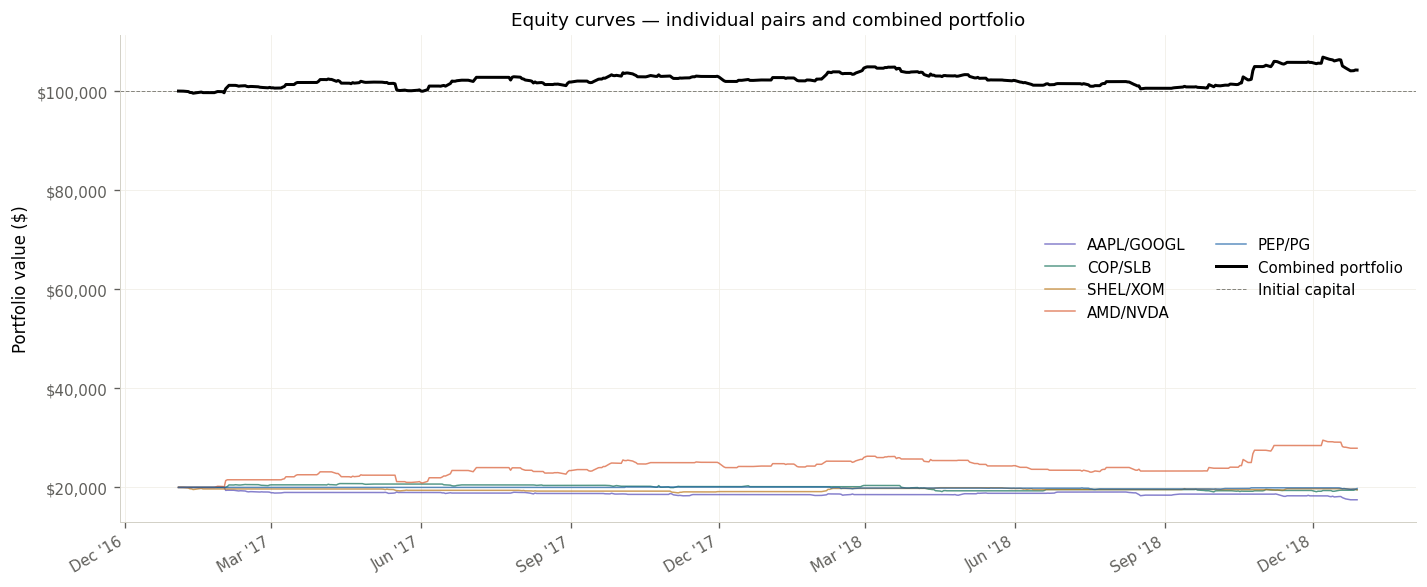

In [13]:
if results_list:
    per_pair_cap = INIT_CAP / len(TOP_PAIRS)

    fig = Plotter.equity_curves(results_list, labels, INIT_CAP, portfolio_equity)
    plt.show()

Each coloured line is an individual pair.
The black line is the combined portfolio (sum of all pair equity curves).
Diversification across uncorrelated pairs reduces individual spikes and smooths the curve.

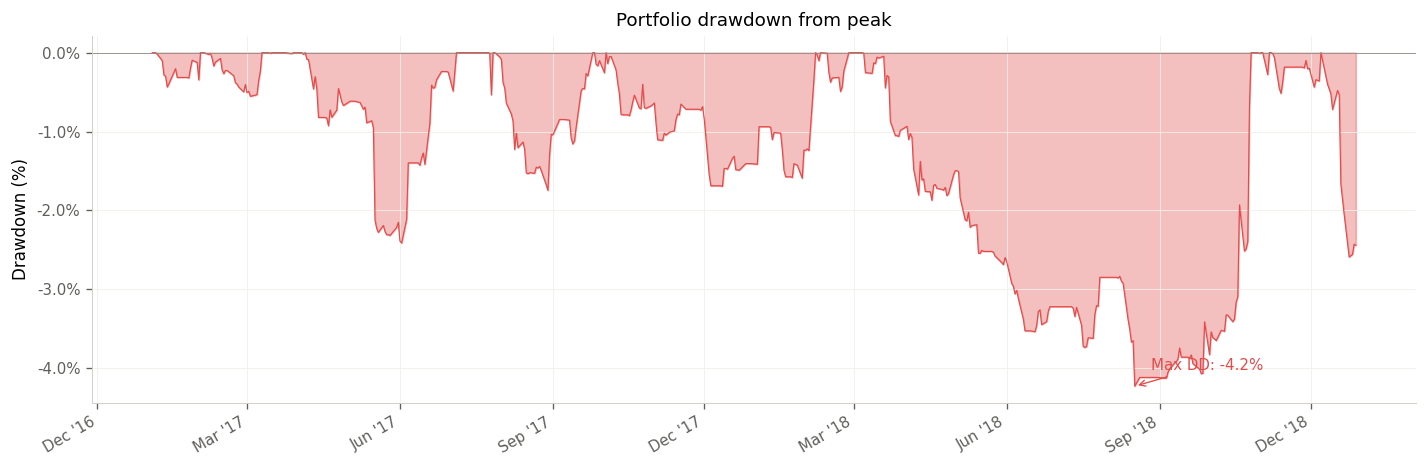

In [14]:
if portfolio_equity is not None:
    fig = Plotter.drawdown_chart(portfolio_equity)
    plt.show()

Drawdown measures peak-to-trough capital decline and is the key path-dependent risk metric.
Short, shallow drawdowns indicate resilient recovery dynamics; deep, prolonged drawdowns indicate fragile risk control.
Compare drawdown depth and duration with your risk budget before trusting headline returns.

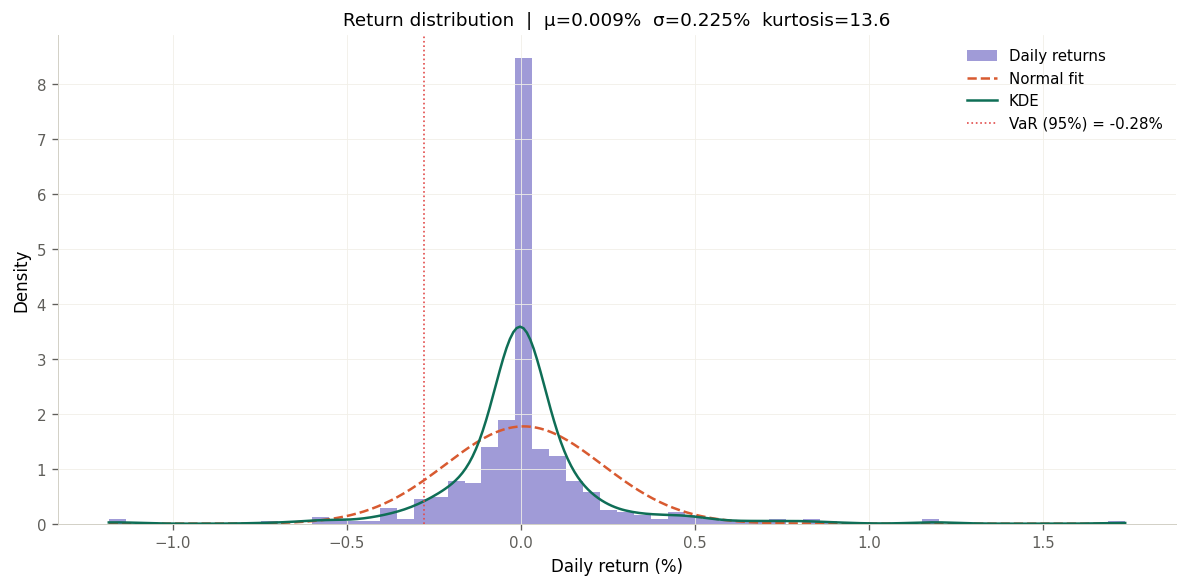

In [15]:
if portfolio_equity is not None:
    fig = Plotter.return_distribution(portfolio_equity)
    plt.show()

The gap between the actual histogram and the normal curve
shows **excess kurtosis** (fat tails). StatArb strategies typically have positive skewness
(many small gains) but occasional large losses, the left tail reveals this asymmetry.
The VaR line marks the daily loss level exceeded only 5% of the time.

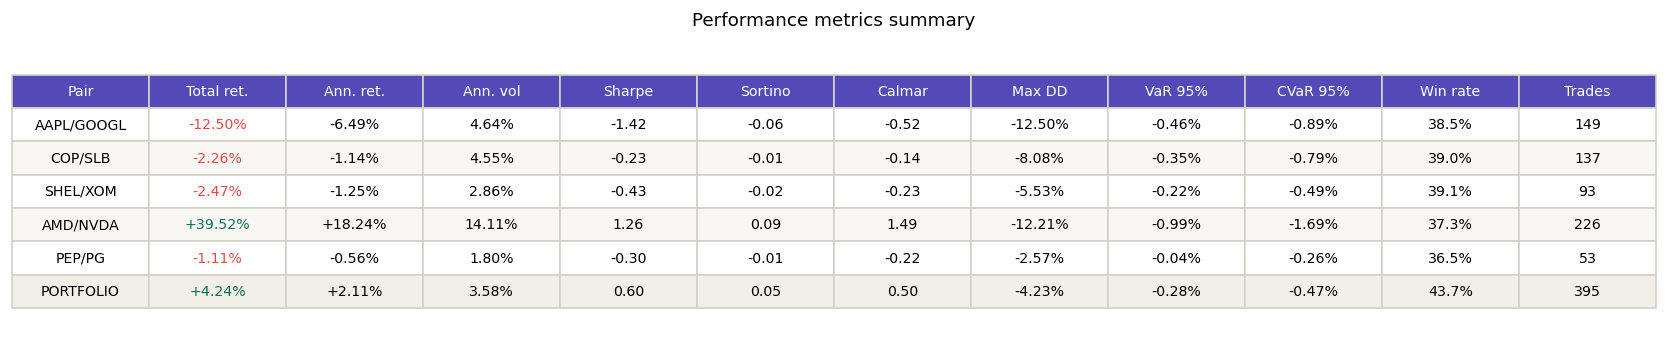

In [16]:
if results_list:
    fig = Plotter.performance_table(
        results_list, labels,
        initial_capital_per_pair=per_pair_cap,
        portfolio_equity=portfolio_equity,
        total_capital=INIT_CAP,
    )
    plt.show()

This table consolidates risk and return metrics across individual pairs and the combined portfolio.
Focus on the quality of returns (Sharpe/Sortino, drawdown, consistency), not only absolute P&L.
The strongest strategy profile combines stable pair-level contributions with controlled portfolio-level downside.

---
## Summary and Conclusions

| Component | Implementation |
|---|---|
| Cointegration test | Engle-Granger two-step (OLS + ADF on residuals) |
| Pair universe | Same-sector only (7 sectors), last 252 training bars for ADF scan |
| Hedge ratio estimation | Kalman Filter (streaming), R=1e-4, Q=diag([1e-6, 1e-6]), warm-start from OLS |
| Signal generation | Z-score = innovation / √S_t, entry ±2σ, exit 0σ (full mean reversion) |
| Position sizing | Adaptive 4-tier (0.5× / 0.75× / 0.9× / 1×) by |z| magnitude, hard stop at |z|=3.5 |
| Execution model | Log-prices, dollar-based, 1-day delay, 5 bps TC, liquidity-adjusted slippage |
| Risk controls | Stop-loss −10%, take-profit +20% per trade |
| ADF guardian | Optional rolling 252-day ADF re-test every 21 days (disabled by default) |
| Portfolio | Equal-weight across top 5 pairs (disjoint tickers), combined equity curve |
| Training period | 2011-01-01 → 2016-12-31 |
| Test period | 2017-01-01 → 2018-12-31 |

**Limitations to be aware of:**
- Short-selling borrowing costs are not modelled (relevant for illiquid or hard-to-borrow stocks).
- Currency risk is ignored for cross-currency pairs.
- Settlement delays (T+2/T+3) are not explicitly modelled.
- Results depend heavily on the stability of cointegration out-of-sample —  
  pairs that pass the ADF test in-sample may diverge structurally in the test period.